In [19]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "GBP_FX_BoE_daily.csv"
TARGET = "target"

## Data Loading and Preprocessing

In [20]:
from fx_forecasting.data.load import load_fx_csv
from fx_forecasting.data.preprocess import prepare_fx_data
from fx_forecasting.data.inspect import inspect_data

df, feature_columns = load_fx_csv(DATA_PATH, date_col='timestamp')

# Assume LSTM model
X_train, y_train, X_test, y_test, scaler = prepare_fx_data(
    df,
    target_col=TARGET,
    test_ratio=0.2,
    add_returns=False,
    add_ma=False,
    add_volatility=False,
    scale=True,
    scaler_type="standard",
    make_windows=True,
    lookback=30
)

# feature_columns = [c for c in columns if c != TARGET]
print(feature_columns)

['GBP_USD', 'GBP_EUR', 'GBP_JPY', 'GBP_KRW', 'GBP_CHF', 'target']


/Users/apple/COMP0197-group-project/src/fx_forecasting/data/load.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df[date_col], errors="coerce")


In [21]:
# Inspect Data
inspect_data(df)


Shape: (1515, 7)

Columns:
['timestamp', 'GBP_USD', 'GBP_EUR', 'GBP_JPY', 'GBP_KRW', 'GBP_CHF', 'target']

First rows:
   timestamp  GBP_USD  GBP_EUR   GBP_JPY    GBP_KRW  GBP_CHF  target
0 2020-02-28   1.2776   1.1630  137.9169  1544.9761   1.2371  8.9312
1 2020-03-02   1.2748   1.1454  137.5764  1520.2118   1.2234  8.8720
2 2020-03-03   1.2819   1.1465  137.8683  1522.1922   1.2250  8.9193
3 2020-03-04   1.2821   1.1511  137.5437  1518.9295   1.2252  8.8778
4 2020-03-05   1.2922   1.1550  137.8777  1536.0123   1.2285  8.9635

Data types:
timestamp    datetime64[us]
GBP_USD             float64
GBP_EUR             float64
GBP_JPY             float64
GBP_KRW             float64
GBP_CHF             float64
target              float64
dtype: object

Missing values:
timestamp    0
GBP_USD      0
GBP_EUR      0
GBP_JPY      0
GBP_KRW      0
GBP_CHF      0
target       0
dtype: int64

Date range:
Start: 2020-02-28 00:00:00
End: 2026-02-27 00:00:00

Observed time gaps:
timestamp
1 days    119

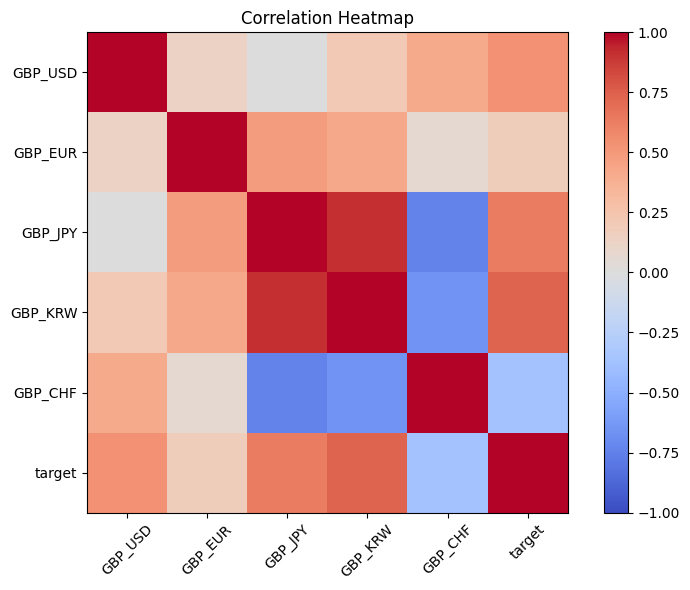

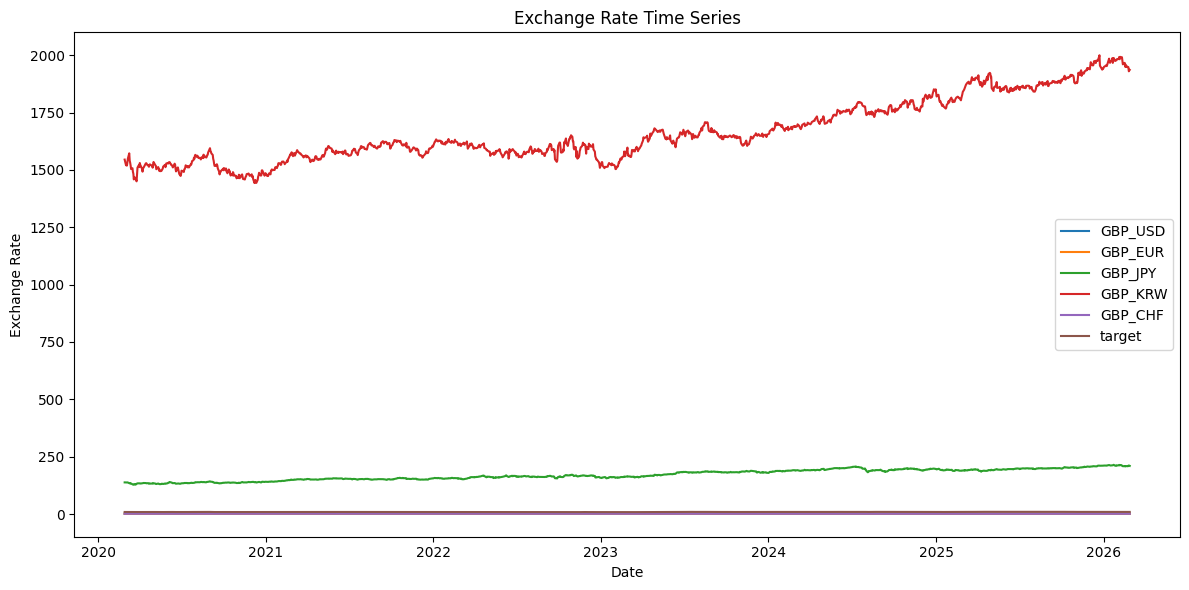

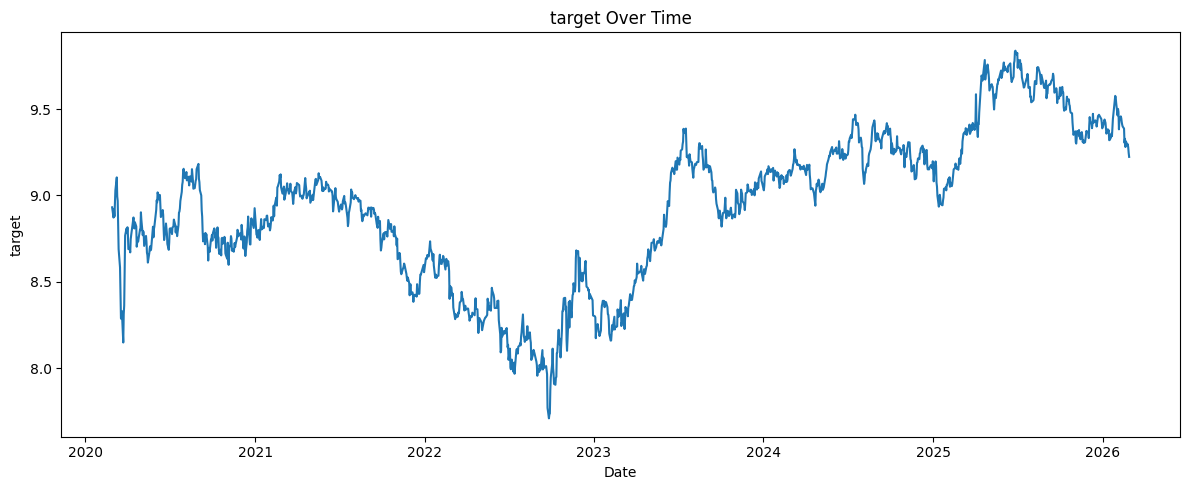

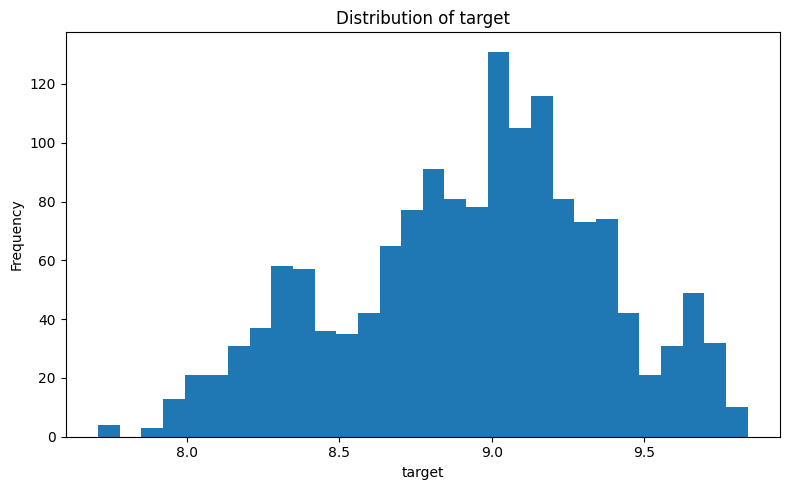

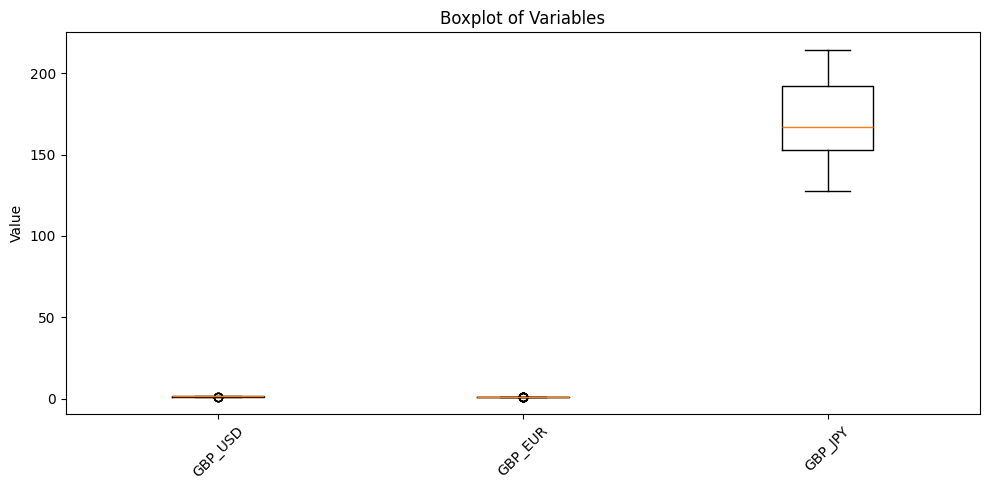

In [22]:
# visualisations

from fx_forecasting.visualization.plots import (
    plot_all_series,
    plot_target_series,
    plot_histogram,
    plot_boxplot,
    plot_correlation_heatmap
)

plot_correlation_heatmap(df)
plot_all_series(df)
plot_target_series(df, TARGET)
plot_histogram(df, TARGET)
plot_boxplot(df, cols=feature_columns[:3])

## Model Training

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 50
BATCH_SIZE = 64


In [24]:
# Data loaders
from torch.utils.data import TensorDataset, DataLoader

# convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_test_t, y_test_t)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [25]:
from fx_forecasting.models.baseline import DeterministicLSTM
from fx_forecasting.training.train import train_model


model = DeterministicLSTM(
    input_dim=len(feature_columns),
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS
)

# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss() 
device = "cuda" if torch.cuda.is_available() else "cpu"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    device=device,
    save_path="best_baseline_model.pt",
    early_stopping_patience=5
)

Epoch 1/50 [Val]: 100%|██████████| 5/5 [00:00<00:00, 156.47it/s]


Epoch 1/50 | Train Loss: 0.7981 | Val Loss: 0.9810 | Train MAE: 0.7341 | Val MAE: 0.8835 | Train RMSE: 0.8790 | Val RMSE: 0.9326
Saved best model at epoch 1 with val loss 0.9810


Epoch 2/50 [Val]: 100%|██████████| 5/5 [00:00<00:00, 163.35it/s]


Epoch 2/50 | Train Loss: 0.1419 | Val Loss: 0.6276 | Train MAE: 0.2960 | Val MAE: 0.6658 | Train RMSE: 0.3696 | Val RMSE: 0.7220
Saved best model at epoch 2 with val loss 0.6276


Epoch 3/50 [Val]: 100%|██████████| 5/5 [00:00<00:00, 197.08it/s]


...

Epoch 43/50 | Train Loss: 0.0190 | Val Loss: 0.0689 | Train MAE: 0.1055 | Val MAE: 0.2123 | Train RMSE: 0.1367 | Val RMSE: 0.2475


Epoch 44/50 [Val]: 100%|██████████| 5/5 [00:00<00:00, 215.01it/s]


Epoch 44/50 | Train Loss: 0.0177 | Val Loss: 0.0820 | Train MAE: 0.1015 | Val MAE: 0.2266 | Train RMSE: 0.1322 | Val RMSE: 0.2624


Epoch 45/50 [Val]: 100%|██████████| 5/5 [00:00<00:00, 215.67it/s]

Epoch 45/50 | Train Loss: 0.0185 | Val Loss: 0.0651 | Train MAE: 0.1053 | Val MAE: 0.2073 | Train RMSE: 0.1352 | Val RMSE: 0.2420
Early stopping at epoch 45
Best model was from epoch 40 with val loss 0.0626


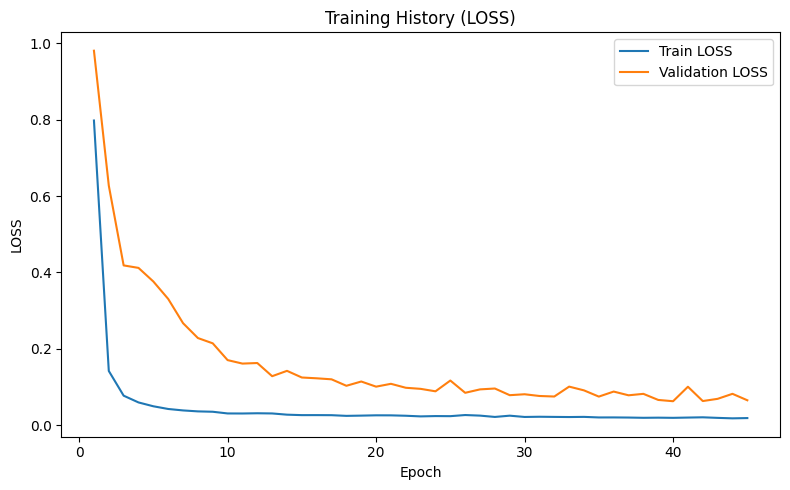

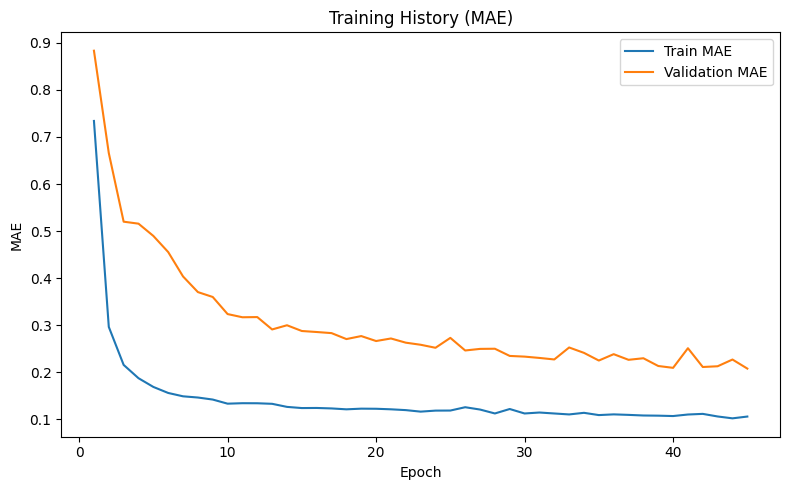

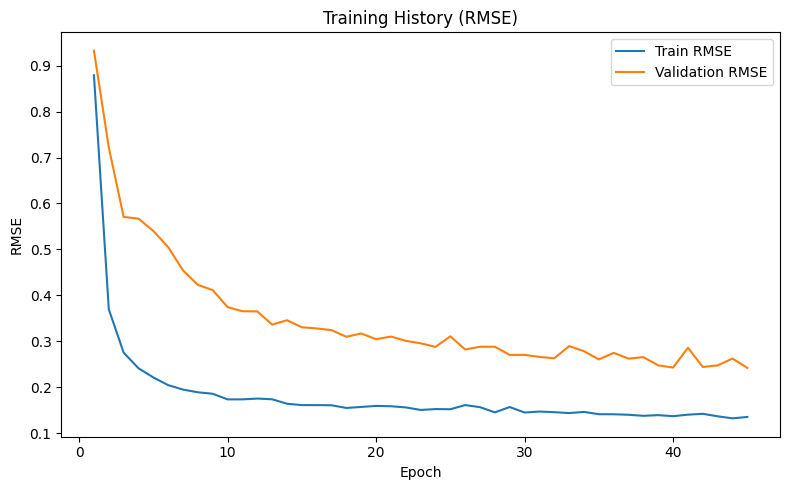

In [26]:
from fx_forecasting.visualization.plots import plot_training_history

plot_training_history(history, metric="loss")
plot_training_history(history, metric="mae")
plot_training_history(history, metric="rmse")

## Evaluation 


Evaluation metrics:
MSE: 0.068178
RMSE: 0.261109
MAE: 0.211117


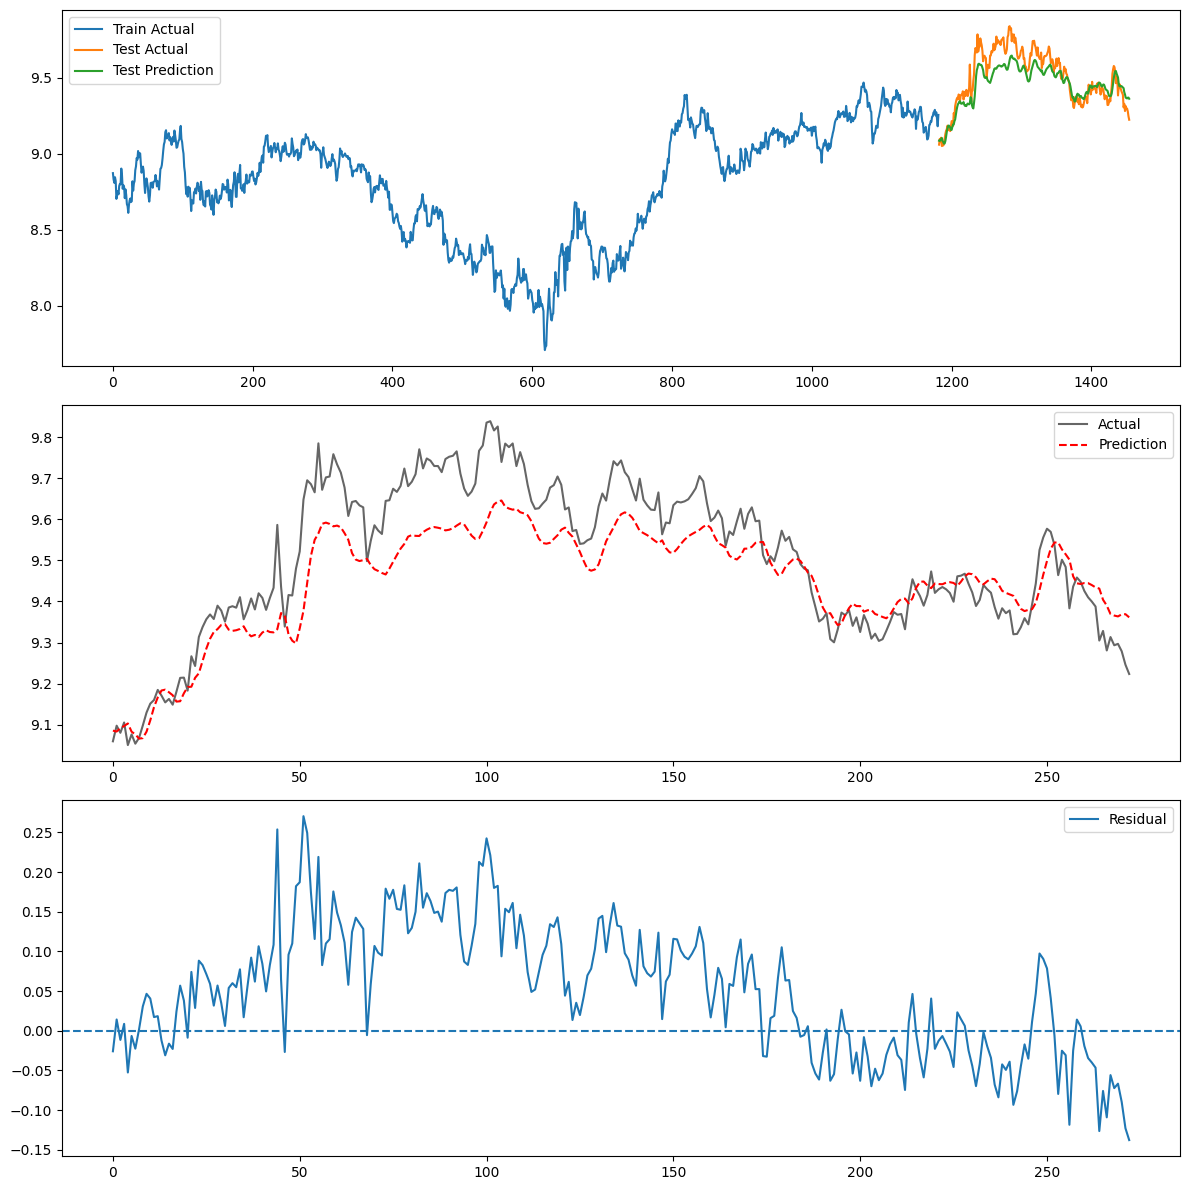

In [27]:
from fx_forecasting.training.evaluate import evaluate_model
from fx_forecasting.visualization.plots import plot_predictions
from fx_forecasting.data.preprocess import inverse_transform_target


preds, targets, metrics = evaluate_model(
    model,
    val_loader,
    device=device
)

# inverse transform
preds_original = inverse_transform_target(
    preds,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

targets_original = inverse_transform_target(
    targets,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

y_train_original = inverse_transform_target(
    y_train,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

plot_predictions(
    preds=preds_original,
    targets=targets_original,
    train_targets=y_train_original
)